In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

/tmp/ipykernel_184925/1214597189.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


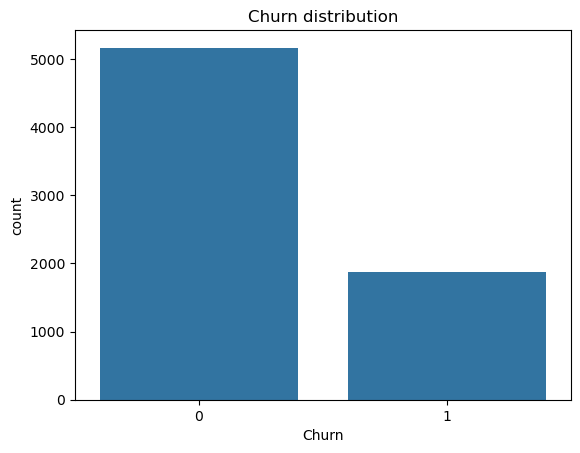

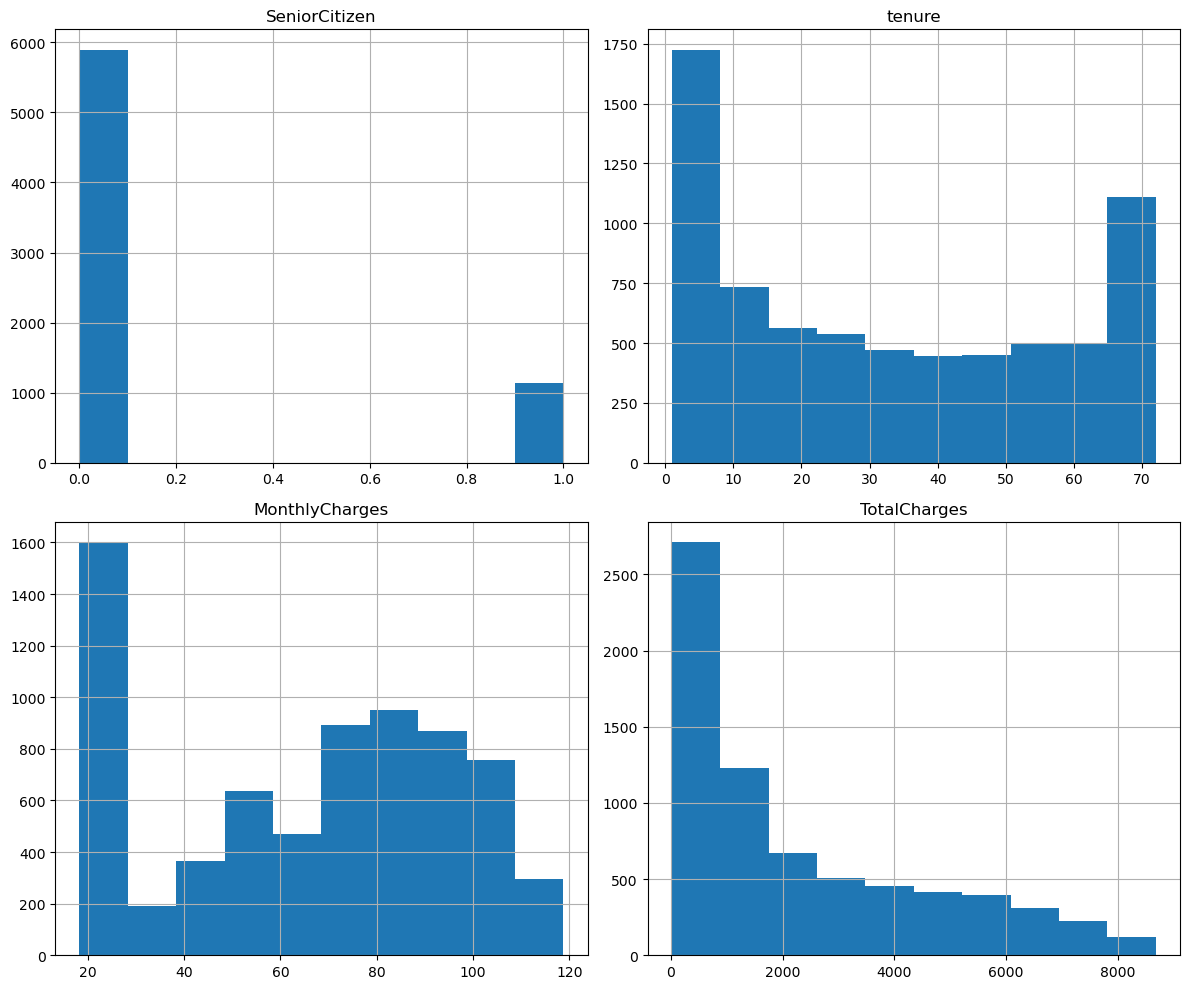

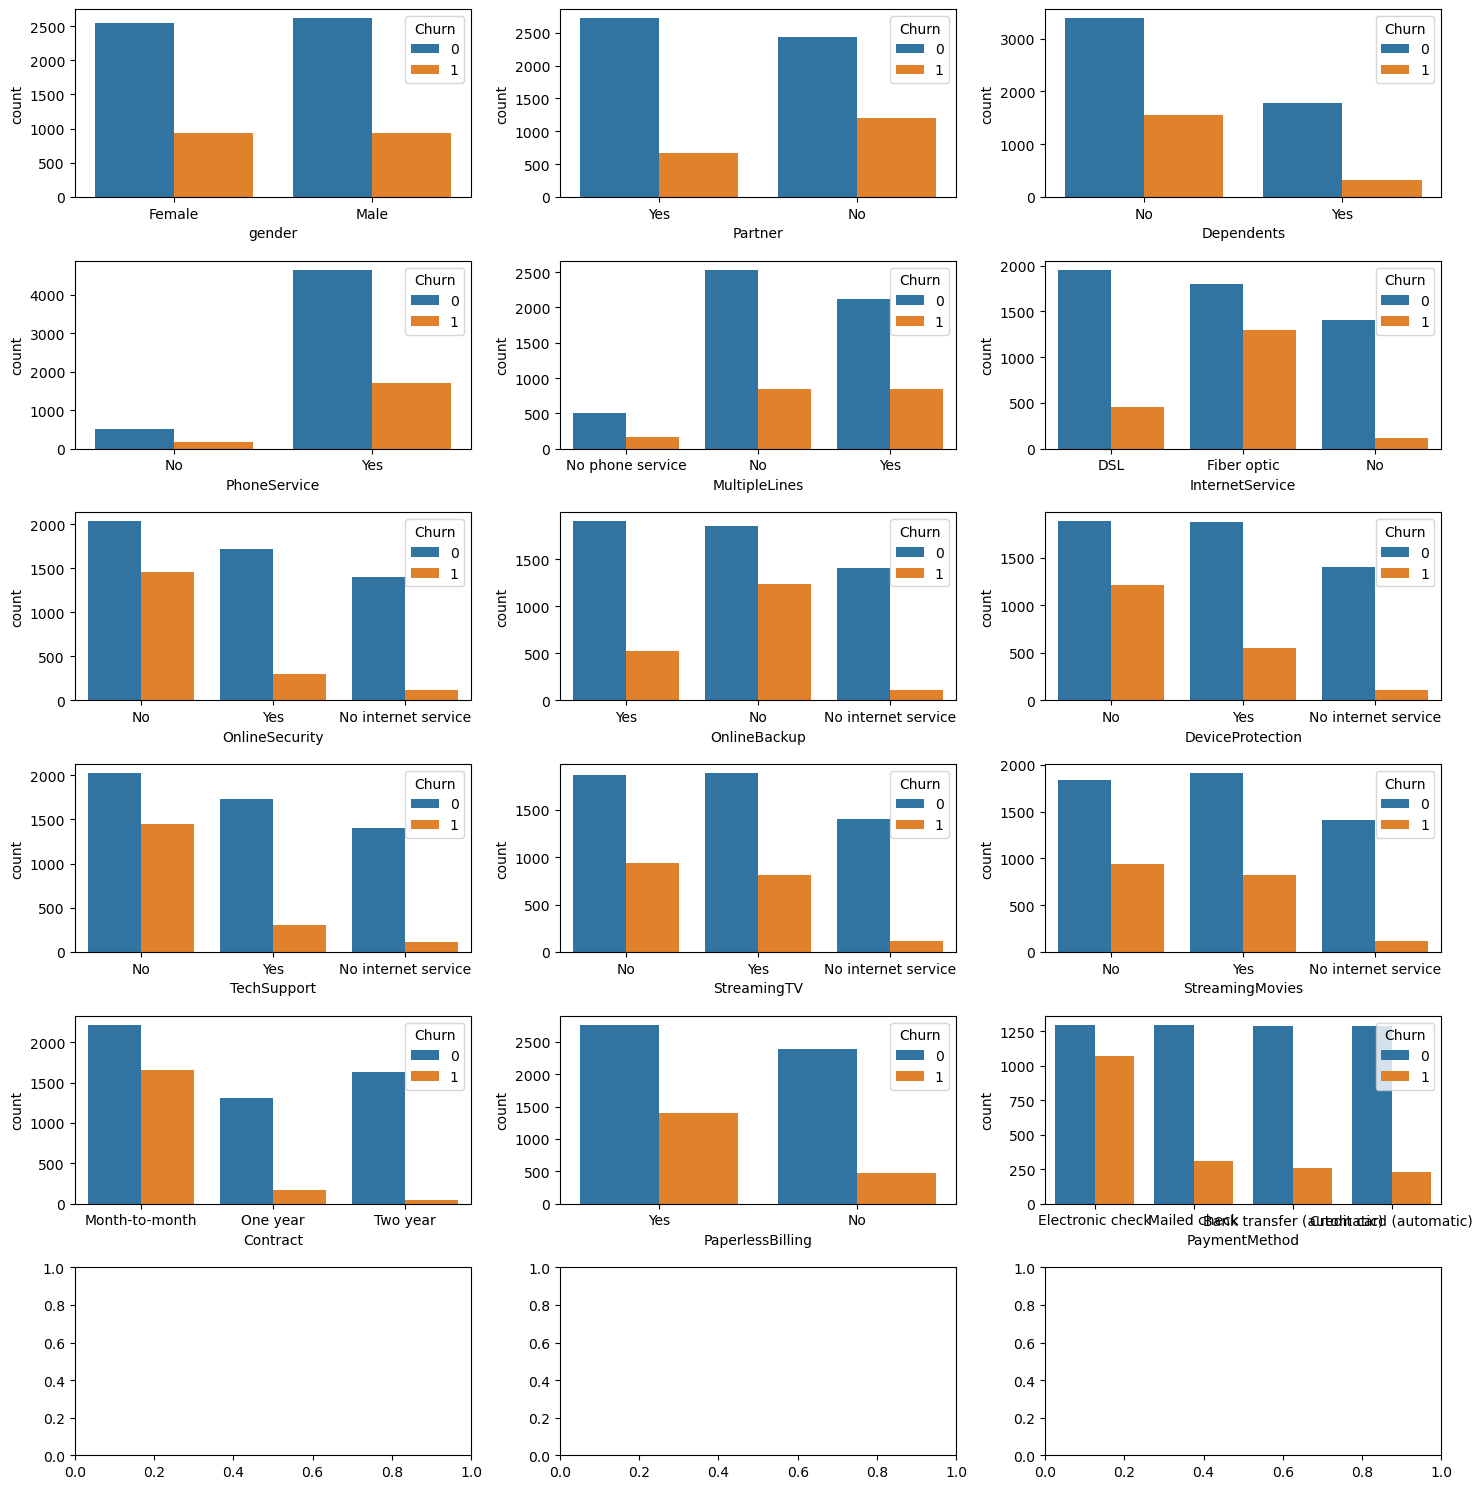

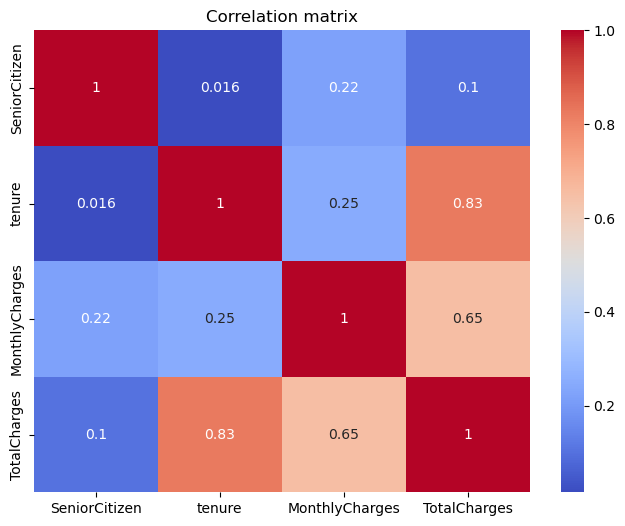

<Axes: xlabel='Contract'>

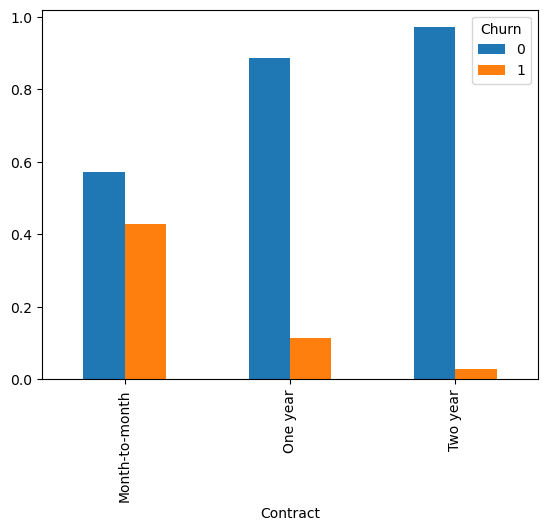

In [9]:
df.info()

df['Churn'].value_counts(normalize=True)

df.isnull().sum()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')  # убираем целевую переменную
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'customerID' in cat_cols:
    cat_cols.remove('customerID')
    df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

sns.countplot(x='Churn', data=df)
plt.title('Churn distribution')
plt.show()

df[num_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=len(cat_cols)//3 + 1, ncols=3, figsize=(15, 15))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar')

## Выводы по EDA

1. **Целевая переменная** несбалансирована (26.5% оттока). Используем ROC-AUC.
2. **Наиболее важные признаки** для предсказания оттока:
   - Тип контракта (Month-to-month → высокий риск)
   - Наличие услуг TechSupport / OnlineSecurity
   - Способ оплаты (Electronic check)
   - Ежемесячные платежи и стаж клиента
3. **Данные чистые**, пропуски только в TotalCharges (удалены). Дальше:
   - Применить OneHotEncoder для категориальных признаков
   - Масштабировать числовые (tenure, MonthlyCharges, TotalCharges)
   - Обучить baseline (логистическая регрессия), затем RandomForest и MLP